# Plateau’s Problem (or minimal surface problem)

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d

torch.manual_seed(0)

device = 'cpu' ## TODO
torch.set_default_device(device)

### Define the boundary rectangles

In [2]:
def get_boundary_angled_rectangles(n=1000):
    ls = lambda a,b : torch.linspace(a, b, n//8, device=device)
    const = lambda c : c*torch.ones(n//8, device=device, dtype=torch.float32)
    bndry = torch.hstack([
        torch.vstack([ls(0,1), const(0), const(0)]),
        torch.vstack([ls(0,1), const(1), const(0)]),
        torch.vstack([const(0), const(0), ls(0,1)]),
        torch.vstack([const(0), ls(0,1), const(1)]),
        torch.vstack([const(0), const(1), ls(0,1)]),
        torch.vstack([const(1), const(0), ls(0,1)]),
        torch.vstack([const(1), ls(0,1), const(1)]),
        torch.vstack([const(1), const(1), ls(0,1)]),
        ]).T
    return bndry

pts_bndry = get_boundary_angled_rectangles()

pts_corners = torch.tensor([
    [0,0,0],
    [1,0,0],
    [1,0,1],
    [1,1,1],
    [1,1,0],
    [0,1,0],
    [0,1,1],
    [0,0,1],
    [0,0,0],
    ], dtype=torch.float32)

bounds = torch.vstack([pts_bndry.min(0).values, pts_bndry.max(0).values]).T

fig = k3d.plot()
fig += k3d.points(pts_bndry.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

In [3]:
from torch import nn
from torch import tanh

class GeneralNet(nn.Module):
    def __init__(self, ks, act=tanh):
        super(GeneralNet, self).__init__()
        self.ks = ks
        self.fcs = nn.ModuleList([nn.Linear(in_features, out_features)
            for in_features, out_features in zip(self.ks[:-1],self.ks[1:])])
        self.D = len(self.fcs)
        self.act = act

    def forward(self, x):
        x = self.fcs[0](x)
        for i in range(2,self.D+1):
            x = self.fcs[i-1](self.act(x))
        return x

In [4]:
from torch.func import vmap, jacrev, jacfwd, functional_call

model = GeneralNet(ks=[3, 32, 32, 1])

params = dict(model.named_parameters())
def f(params, x):
    return functional_call(model, params, x)

## Jacobian of f with respect to the input x
f_x = jacrev(f, argnums=1)  ## params, [nx] -> [ny, nx]
vf_x = vmap(f_x, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx]
## Hessian of f with respect to the input x
f_xx = jacfwd(f_x, argnums=1)  ## params, [nx] -> [ny, nx, nx]
vf_xx = vmap(f_xx, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx, nx]
# Laplacian of f with respect to the input x
def laplacian_f(params, x):
    hessian = f_xx(params, x).squeeze(1)  # Compute the Hessian
    laplacian = torch.einsum('bii->b', hessian)  # Sum of the diagonal elements to get the Laplacian
    return laplacian
v_laplacian_f = vmap(laplacian_f, in_dims=(None, 0), out_dims=(0))
## Phi (Gradients of f wrt theta)
f_theta = jacrev(f, argnums=0)  # dict
vf_theta = vmap(f_theta, in_dims=(None, 0), out_dims=(0))
## Grad Phi (Gradients of Phi wrt x)
phi_x = jacfwd(f_theta, argnums=1)  # dict
v_phi_x = vmap(phi_x, in_dims=(None, 0), out_dims=(0))
## Laplacian of Phi
laplacian_phi = jacrev(laplacian_f, argnums=0) # dict
v_laplacian_phi = vmap(laplacian_phi, in_dims=(None, 0), out_dims=(0))

### Calculate Hessian approximations

In [5]:
# Approximate Hessians

def calculate_A_interface_diag(params, pts_bndry):
    """
    Calculate the diagonal of boundary integral matrix A_bndry.
    
    Args:
        vf_theta: Function mapping parameters and points to derivatives (jacobian).
        params: Model parameters as a dictionary.
        pts_bndry: Boundary points as a tensor of shape [n_points, n_dims].
        interface_length: Length of the interface for scaling (default: 8).
        
    Returns:
        torch.Tensor: Approximate diagonal of Hessian of the boundary loss [n_params].
    """
    # Compute φ_i at boundary points
    phi_at_pts = vf_theta(params, pts_bndry)  # Returns a dict

    # Aggregate φ_i into a single tensor
    phi_at_pts_tensor = torch.cat([p.flatten(start_dim=1) for p in phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_bndry = torch.einsum('bi,bi->i', phi_at_pts_tensor, phi_at_pts_tensor) / len(pts_bndry)

    return A_bndry.detach()

def calculate_A_eikonal_diag(params, pts):
    """
    Calculate the diagonal of eikonal integral matrix A_eikonal.
    
    Args:
        v_phi_x: Function mapping parameters and points to gradients of phi (jacobian).
        vf_x: Function mapping parameters and points to gradients of f (jacobian).
        params: Model parameters as a dictionary.
        pts: Points in the space as a tensor of shape [n_points, n_dims].
        
    Returns:
        torch.Tensor: Approximate diagonal of Hessian of the eikonal loss [n_params].
    """
    grad_phi_at_pts = v_phi_x(params, pts)  # Returns a dict
    grad_f_at_pts = vf_x(params, pts)  # Returns a tensor of shape [n_points, 1, n_dims]
    grad_f_at_pts = grad_f_at_pts / torch.norm(grad_f_at_pts, dim=-1, keepdim=True)**(1.5)

    # Aggregate gradients into a single tensor
    grad_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in grad_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params * n_dims]
    # Reshape to separate the dimensions
    n_points, n_params_times_dims = grad_phi_tensor.shape
    n_dims = pts.shape[1]
    n_params = n_params_times_dims // n_dims
    grad_phi_tensor = grad_phi_tensor.reshape(n_points, n_params, n_dims)  # Shape: [n_points, n_params, n_dims]
    A_eikonal_diag = torch.einsum('bik,bik->i', grad_phi_tensor, grad_phi_tensor)/n_points

    cross_product_term = torch.cross(grad_phi_tensor, grad_f_at_pts, dim=-1)
    cross_product_term = torch.einsum('bik,bik->i', cross_product_term, cross_product_term)/n_points
    A_eikonal_diag -= cross_product_term
    return A_eikonal_diag.detach()


def calculate_A_laplacian_diag(params, pts):
    """
    Calculate the diagonal of Laplacian integral matrix A_laplacian.
    
    Args:
        vf_theta_lap: Function mapping parameters and points to Laplacians (second derivatives).
        params: Model parameters as a dictionary.
        pts: Surface points as a tensor of shape [n_points, n_dims].
        
    Returns:
        torch.Tensor: Approximate diagonal of Hessian of the laplacian loss [n_params].
    """
    # Compute Laplacians of φ_i at points
    lap_phi_at_pts = v_laplacian_phi(params, pts)  # Returns a dict
    
    # Aggregate Laplacians into a single tensor
    lap_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in lap_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_laplacian_diag = torch.einsum('bi,bi->i', lap_phi_tensor, lap_phi_tensor) / len(pts)

    return A_laplacian_diag.detach()

def compute_hessian_diag(params, pts, t):
    """
    Compute the diagonal of the Hessian matrix.
    
    Args:
        params: Model parameters as a dictionary.
        
    Returns:
        torch.Tensor: Diagonal of the Hessian matrix [n_params].
    """
    A_diag = 2 * (calculate_A_interface_diag(params, pts_bndry) + 10*calculate_A_interface_diag(params, pts_corners))
    A_diag += 2 * (calculate_A_eikonal_diag(params, pts_bndry) + 10*calculate_A_eikonal_diag(params, pts_corners))
    if t >= 1000:
        A_diag += 2* calculate_A_laplacian_diag(params, pts)
    return A_diag.detach()

def spatial_average_hessian_diagonal(D, block_size=1):
    """
    Spatially average the Hessian diagonal D in blocks of size block_size.

    Args:
        D (torch.Tensor): 1D tensor representing Hessian diagonal (size = d).
        block_size (int): block size used to average.

    Returns:
        torch.Tensor: the spatially averaged Hessian diagonal D^(s).
    """
    d = D.numel()
    if d % block_size != 0:
        raise ValueError("d must be divisible by block_size for this simple block averaging.")

    # Reshape D so that each row is a block
    D_blocks = D.view(-1, block_size)
    # Average each row
    D_avg = D_blocks.mean(dim=1, keepdim=True)
    # Broadcast back to original shape
    D_s = D_avg.expand_as(D_blocks).reshape(d)
    return D_s

In [6]:
class HandAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        """
        params: iterable of torch.Parameters (e.g. model.parameters())
        lr: learning rate
        betas: (beta1, beta2) coefficients
        eps: small number for numerical stability
        """
        self.params = list(params)  # store references to model parameters
        self.lr = lr
        self.betas = betas
        self.eps = eps

        self.t = 0  # keep track of update steps
        # For each param, maintain its own m (first moment) and v (second moment)
        self.m = [torch.zeros_like(p, memory_format=torch.preserve_format) for p in self.params]
        self.v = [torch.zeros_like(p, memory_format=torch.preserve_format) for p in self.params]

    def zero_grad(self):
        """Set gradients of all optimized parameters to zero."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        """
        Perform a single Adam update step on all parameters.
        """
        self.t += 1
        beta1, beta2 = self.betas

        for i, param in enumerate(self.params):
            if param.grad is None:
                continue

            g = param.grad  # gradient
            self.m[i] = beta1 * self.m[i] + (1 - beta1) * g      # update first moment
            self.v[i] = beta2 * self.v[i] + (1 - beta2) * (g*g)  # update second moment

            # Correct bias in moments
            m_hat = self.m[i] / (1 - beta1**self.t)
            v_hat = self.v[i] / (1 - beta2**self.t)

            # Update parameter
            param.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

class HandAdaHessian:
    def __init__(self,
                 params,
                 pts,
                 lr=1e-3,
                 betas=(0.9, 0.999),
                 eps=1e-8,
                 block_size=1):
        """
        Custom AdaHessian-like optimizer.

        Args:
            model      : torch.nn.Module, or anything with .parameters().
            lr         : learning rate
            betas      : Adam-like betas (beta1, beta2)
            eps        : numerical stability term
            block_size : size of the block for spatial averaging of Hessian diag
        """
        self.params = list(params)
        self.pts = pts
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.block_size = block_size

        self.t = 0
        # For each param, store first moment (m) and second moment (v)
        self.m = [torch.zeros_like(p, memory_format=torch.preserve_format) for p in self.params]
        self.v = [torch.zeros_like(p, memory_format=torch.preserve_format) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        """
        Perform a single AdaHessian-like update step.
        We:
          1) get the gradient g
          2) compute Hessian diagonal -> approximate or exact
          3) optionally block-average the Hessian diagonal
          4) update the first and second moments
          5) param update
        """
        self.t += 1
        beta1, beta2 = self.betas

        # =========================================================
        # 1) Gradients are already in param.grad after backward()
        # 2) Compute Hessian diagonal w.r.t. model parameters
        # =========================================================
        hess_diag_full = compute_hessian_diag(params, self.pts, self.t)  # shape [sum_of_param_sizes]
        # Optionally block average:
        if self.block_size > 1:
            hess_diag_full = spatial_average_hessian_diagonal(hess_diag_full, self.block_size)

        # We'll split hess_diag_full back into param-shaped slices
        param_sizes = [p.numel() for p in self.params]
        splits = torch.split(hess_diag_full, param_sizes)

        # =========================================================
        # 3) Adam-like update for each param, but second moment uses Hessian diag
        # =========================================================
        for i, param in enumerate(self.params):
            g = param.grad
            if g is None:
                continue

            # First moment: standard Adam momentum w.r.t. gradient
            self.m[i] = beta1 * self.m[i] + (1 - beta1) * g

            # Second moment: AdaHessian uses the Hessian diagonal instead of g^2
            D_s = splits[i].view_as(param)  # block-averaged Hess diag for this param
            self.v[i] = beta2 * self.v[i] + (1 - beta2) * D_s

            # Bias-corrected first and second moments
            m_hat = self.m[i] / (1 - beta1**self.t)
            v_hat = self.v[i] / (1 - beta2**self.t)

            # AdaHessian update:
            # param.data = param.data - lr * m_hat / (sqrt(v_hat) + eps)
            # Just like Adam, but v_hat is Hess diag instead of g^2
            param.data -= self.lr * m_hat / (torch.sqrt(torch.abs(v_hat)) + self.eps)

### Main training loop

In [7]:
# def boundary_loss(params, pts_bndry):
#     return f(params, pts_bndry).square().mean()

# def eikonal_loss(params, pts_eik):
#     return (vf_x(params, pts_eik).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

# def laplacian_loss(params, pts):
#     return v_laplacian_f(params, pts).square().mean()

lr_init = 1e-3
# optim = torch.optim.Adam(model.parameters(), lr=lr_init)
# optim = HandAdam(model.parameters(), lr=lr_init)
optim = HandAdaHessian(model.parameters(), pts_bndry, lr=lr_init, block_size=1)

pts_bndry_clone = pts_bndry.clone()
pts_corners_clone = pts_corners.clone()

loss_over_iters = {}

for i in (pbar:=trange(10000)):
    # if i == 1000:
    #     optim = torch.optim.SGD(model.parameters(), lr=1e-3)
    optim.zero_grad()
    params_clone = {key: tensor.clone().detach() for key, tensor in params.items()}

    ## 1) Interface at boundaries
    loss_interface  = f(params, pts_bndry).square().mean()
    loss_interface += 10*f(params, pts_corners).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = (vf_x(params, pts_bndry).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    loss_eikonal += 10*(vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    ## 3) Mean curvature on the 0-surface
    if i<1000:
        # loss_curvature = torch.zeros([1,1])
        loss_laplacian = torch.zeros([1,1])
        pts = []
        with torch.no_grad():
            h_interface, h_eikonal, h_laplacian = 1.0, 1.0, 1.0

    else:
        ## Sample points on surface
        pts = torch.rand([10000, 3])
        # pts_clone = pts.clone().detach()
        vals_sq = model(pts).square().squeeze()
        pts = pts[vals_sq<1e-4]
        optim.pts = pts
        laplacian = v_laplacian_f(params, pts).squeeze(1)
        loss_laplacian = laplacian.square().mean()
        # if len(pts):
        #     if i % 1000 == 0:
        #         # pts_clone = pts.clone().detach()
        #         vals_sq = model(pts_clone).square().squeeze()
        #         pts_clone = pts_clone[vals_sq<1e-4]
        #         tr_A_interface = torch.trace(2 * (calculate_A_interface(params_clone, pts_bndry_clone) + 10*calculate_A_interface(params_clone, pts_corners_clone))).detach()  # 2 comes from derivative because we don't take 1/2 in the loss
        #         tr_A_eikonal = torch.trace(2 * (calculate_A_eikonal(params_clone, pts_bndry_clone) + 10*calculate_A_eikonal(params_clone, pts_corners_clone))).detach()  # 2 comes from derivative because we don't take 1/2 in the loss
        #         tr_A_laplacian = torch.trace(2 * calculate_A_laplacian(params_clone, pts_clone)).detach()
        #         with torch.no_grad():
        #             tr_A_total = tr_A_interface + tr_A_eikonal + tr_A_laplacian
        #             h_interface, h_eikonal, h_laplacian = tr_A_total/tr_A_interface, tr_A_total/tr_A_eikonal, tr_A_total/tr_A_laplacian
        #             h_total = h_interface + h_eikonal + h_laplacian
        #             h_interface, h_eikonal, h_laplacian = h_interface/h_total, h_eikonal/h_total, h_laplacian/h_total
        #             new_lr = lr_init / (1.0 + 1e-4 * tr_A_total)
        #             # for param_group in optim.param_groups:
        #             #     param_group['lr'] = new_lr
            
   
    loss = h_interface * loss_interface + h_eikonal * loss_eikonal + h_laplacian * loss_laplacian
    loss.backward()
    optim.step()
    # loss = loss.detach()
    with torch.no_grad():
        loss_metric = loss_interface + loss_eikonal + loss_laplacian


        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            # f"curvature: {loss_curvature.item():.2e} "
                            f"laplacian: {loss_laplacian.item():.2e} "
                            f"{len(pts)}"
                            )
        loss_over_iters[i] = loss_metric.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Visualize the result

In [8]:
import sys
sys.path.append('..')
from util.visualization.utils_mesh import get_mesh

verts, faces = get_mesh(model, N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=2)

In [9]:
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
fig.display()

c:\Users\james\Desktop\Studium ETH\Master Thesis\GINN Code\ginn_env\lib\site-packages\traittypes\traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

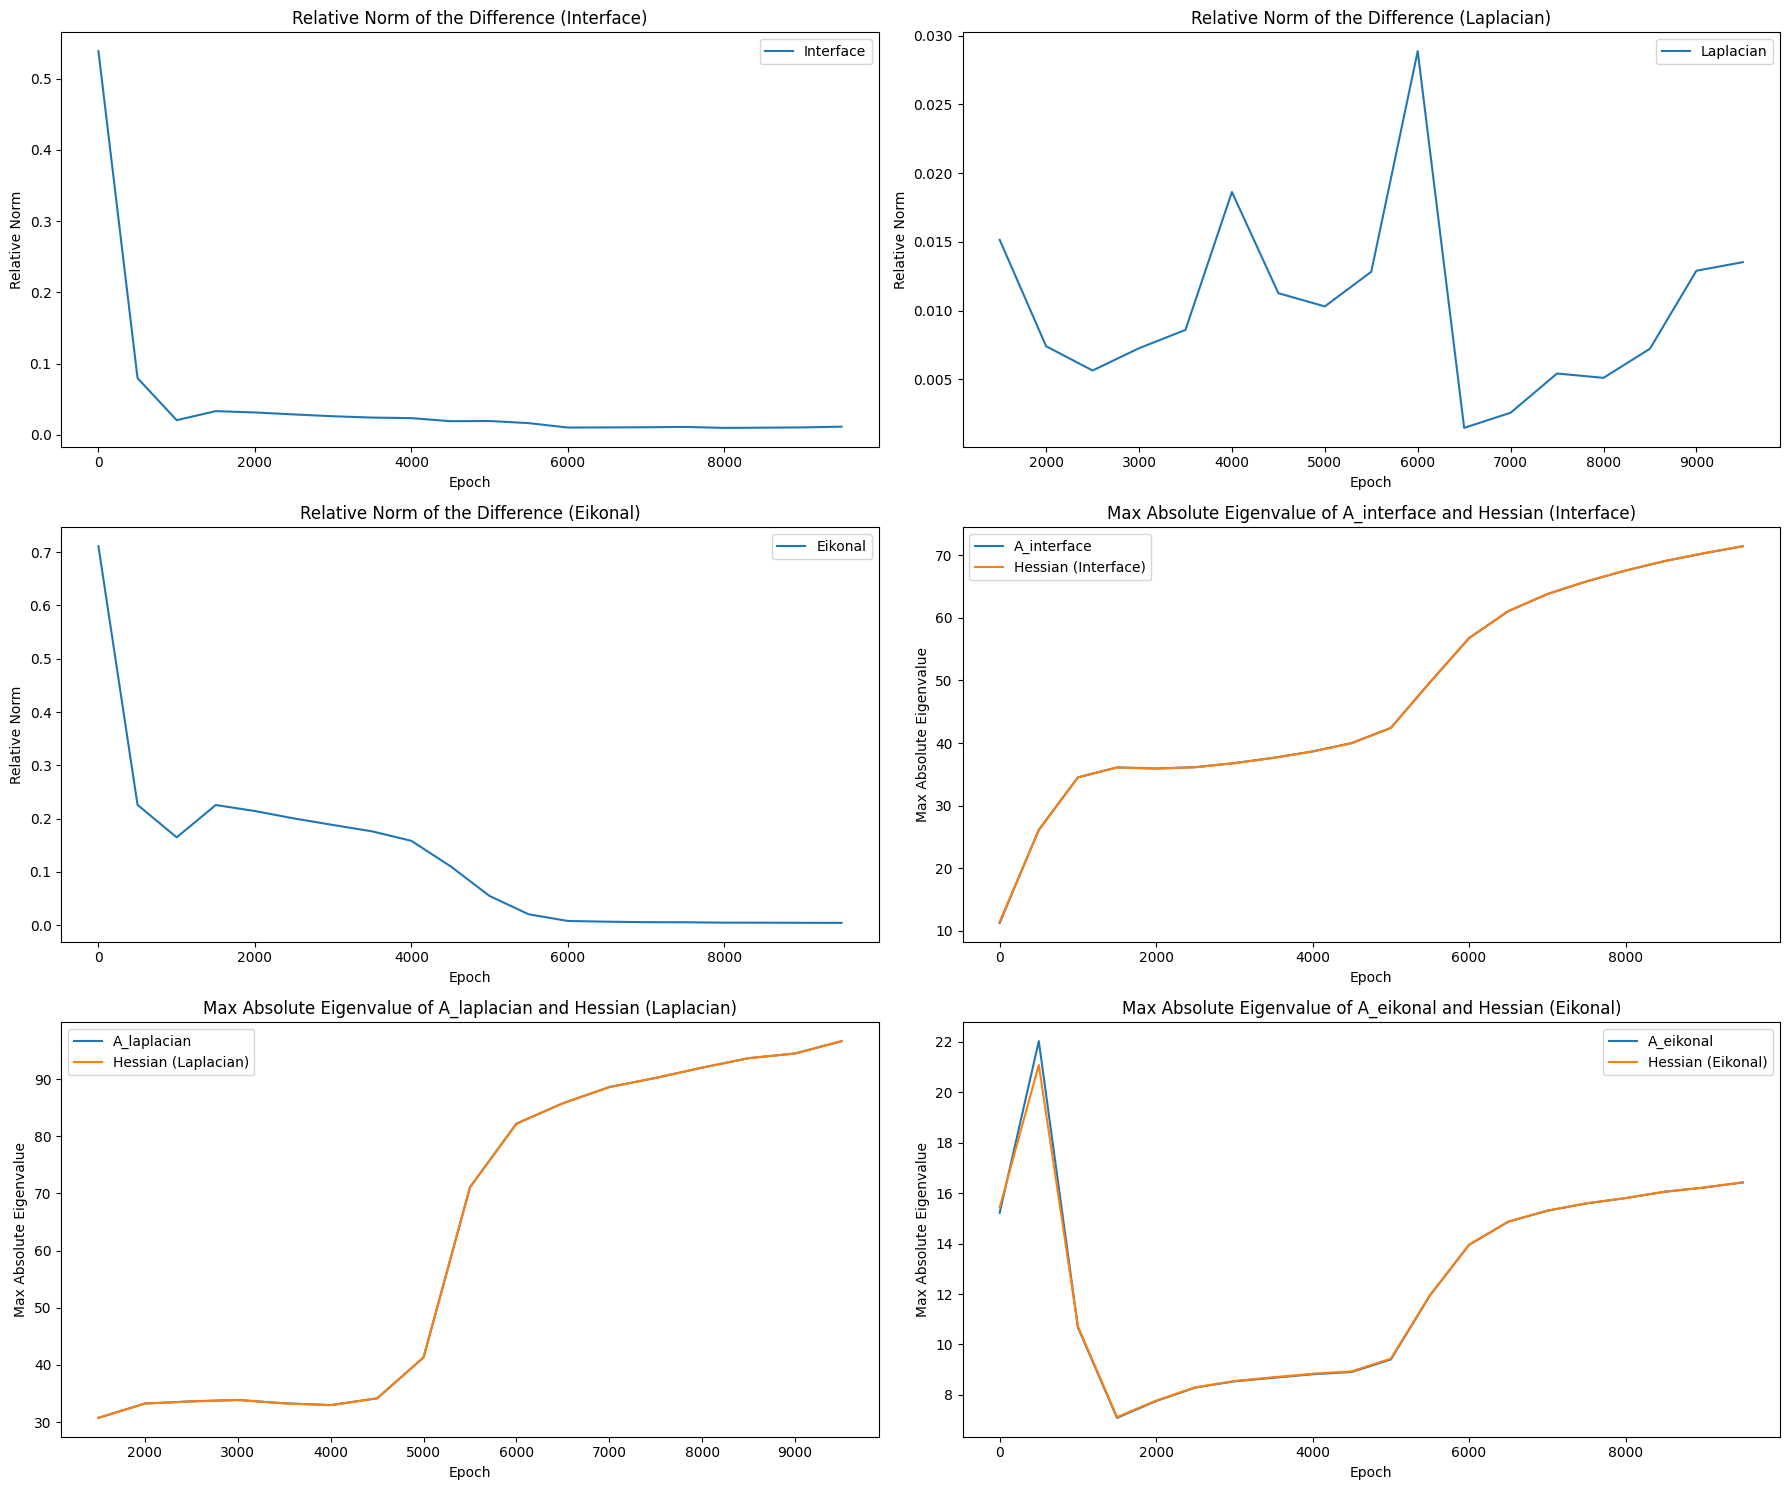

In [9]:
import matplotlib.pyplot as plt

# Plot the logged values
plt.figure(figsize=(18, 15))

# Plot relative norm of the difference (interface)
plt.subplot(3, 2, 1)
plt.plot(log_data['epochs'], log_data['relative_norm_interface'], label='Interface')
plt.xlabel('Epoch')
plt.ylabel('Relative Norm')
plt.title('Relative Norm of the Difference (Interface)')
plt.legend()

# Plot relative norm of the difference (laplacian)
plt.subplot(3, 2, 2)
plt.plot(log_data['epochs'][3:], log_data['relative_norm_laplacian'], label='Laplacian')
plt.xlabel('Epoch')
plt.ylabel('Relative Norm')
plt.title('Relative Norm of the Difference (Laplacian)')
plt.legend()

# Plot relative norm of the difference (eikonal)
plt.subplot(3, 2, 3)
plt.plot(log_data['epochs'], log_data['relative_norm_eikonal'], label='Eikonal')
plt.xlabel('Epoch')
plt.ylabel('Relative Norm')
plt.title('Relative Norm of the Difference (Eikonal)')
plt.legend()

# Plot maximum absolute eigenvalue of A_interface and Hessian (interface)
plt.subplot(3, 2, 4)
plt.plot(log_data['epochs'], log_data['max_abs_eigenvalue_A_interface'], label='A_interface')
plt.plot(log_data['epochs'], log_data['max_abs_eigenvalue_hessian_interface'], label='Hessian (Interface)')
plt.xlabel('Epoch')
plt.ylabel('Max Absolute Eigenvalue')
plt.title('Max Absolute Eigenvalue of A_interface and Hessian (Interface)')
plt.legend()

# Plot maximum absolute eigenvalue of A_laplacian and Hessian (laplacian)
plt.subplot(3, 2, 5)
plt.plot(log_data['epochs'][3:], log_data['max_abs_eigenvalue_A_laplacian'], label='A_laplacian')
plt.plot(log_data['epochs'][3:], log_data['max_abs_eigenvalue_hessian_laplacian'], label='Hessian (Laplacian)')
plt.xlabel('Epoch')
plt.ylabel('Max Absolute Eigenvalue')
plt.title('Max Absolute Eigenvalue of A_laplacian and Hessian (Laplacian)')
plt.legend()

# Plot maximum absolute eigenvalue of A_eikonal and Hessian (eikonal)
plt.subplot(3, 2, 6)
plt.plot(log_data['epochs'], log_data['max_abs_eigenvalue_A_eikonal'], label='A_eikonal')
plt.plot(log_data['epochs'], log_data['max_abs_eigenvalue_hessian_eikonal'], label='Hessian (Eikonal)')
plt.xlabel('Epoch')
plt.ylabel('Max Absolute Eigenvalue')
plt.title('Max Absolute Eigenvalue of A_eikonal and Hessian (Eikonal)')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
import pickle

# Save log_data to a file
with open('log_data.pkl', 'wb') as f:
    pickle.dump(log_data, f)

with open('loss_over_iters.pkl', 'wb') as f:
    pickle.dump(loss_over_iters, f)

# Save the model
torch.save(model.state_dict(), 'model.pth')

In [10]:
import pickle

# Replace 'loss_over_iters.pkl' with the correct file path if needed
with open('loss_over_iters.pkl', 'rb') as f:
    data = pickle.load(f)

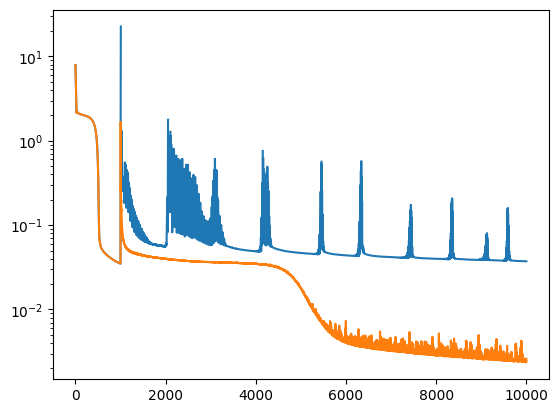

In [19]:
plt.plot(loss_over_iters.keys(), loss_over_iters.values(), label='Loss')
plt.plot(data.keys(), data.values(), label='Loss (Old)')
plt.semilogy()
plt.show()